# 🧠 Face Stats — Preprocessing Starter Notebook

This notebook is the visual sandbox / testing ground for the full
Face Stats preprocessing pipeline.

Here you can:

- Load sample raw face images  
- Inspect resolution / quality  
- Run face detection (MediaPipe)  
- Compute pose (yaw, pitch, roll)  
- Align the face to horizontal  
- Crop to the canonical bounding box  
- Downsample to 512×512  
- Visualize each step  
- Save processed outputs into a working folder  
- Build metadata examples for the larger pipeline  

This notebook should be used before running the full dataset pipeline
to ensure that the aesthetic + technical preprocessing decisions
match the needs of the Face Stats project.

In [1]:
import os
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import mediapipe as mp

# Notebook-friendly plotting
plt.rcParams['figure.figsize'] = (6, 6)

mp_face = mp.solutions.face_mesh.FaceMesh(
    static_image_mode=True,
    refine_landmarks=True,
    max_num_faces=3,
    min_detection_confidence=0.5
)

mp_hands = mp.solutions.hands.Hands(
    static_image_mode=True,
    max_num_hands=4,
    min_detection_confidence=0.4
)

I0000 00:00:1763280281.098189 3332805 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
I0000 00:00:1763280281.103751 3332805 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1763280281.116412 3332905 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763280281.122996 3332910 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763280281.131396 3332905 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763280281.136628 3332911 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


# 📁 Load a Sample Image

Pick any image from your downloaded dataset (e.g. Part 4 — SD 2.1 curated).

Set the `IMG_PATH` variable in the next cell to test specific samples.

This allows you to:
- visually inspect quality  
- verify that preprocessing behaves correctly  
- check realism (no cartooniness)  

Using: /Users/jayklarin/__DI/Repositories/DI_Assignments/FaceStats/dataset_raw/part4_sd21/images/images/SFHQ_pt4_00000001.jpg


(-0.5, 1023.5, 1023.5, -0.5)

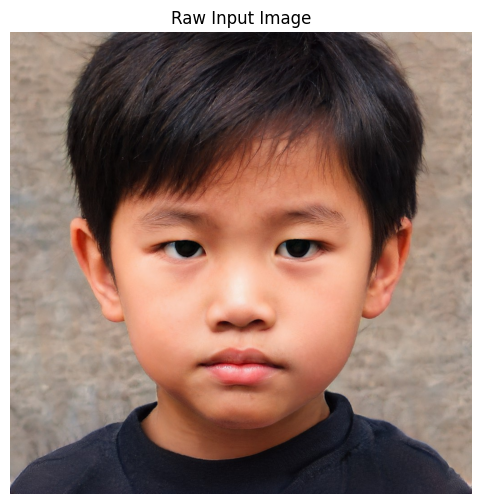

In [8]:
import glob

IMAGE_DIR = "/Users/jayklarin/__DI/Repositories/DI_Assignments/FaceStats/dataset_raw/part4_sd21/images/images"

files = sorted(glob.glob(f"{IMAGE_DIR}/*.jpg"))
assert len(files) > 0, "No images found in IMAGE_DIR — check folder name."

IMG_PATH = files[0]
print("Using:", IMG_PATH)

raw = Image.open(IMG_PATH).convert("RGB")
raw_cv = cv2.cvtColor(np.array(raw), cv2.COLOR_RGB2BGR)

plt.imshow(raw)
plt.title("Raw Input Image")
plt.axis("off")


# 🧩 Face & Hand Detection (Quality Gate)

Here we test:
- whether MediaPipe detects the face  
- whether there are multiple faces  
- whether hands appear (distractors)  
- the landmark mesh structure  

This cell is key to replicating Gate 2 + Gate 3 from your dataset plan.

W0000 00:00:1763281079.522214 3332900 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


(-0.5, 1023.5, 1023.5, -0.5)

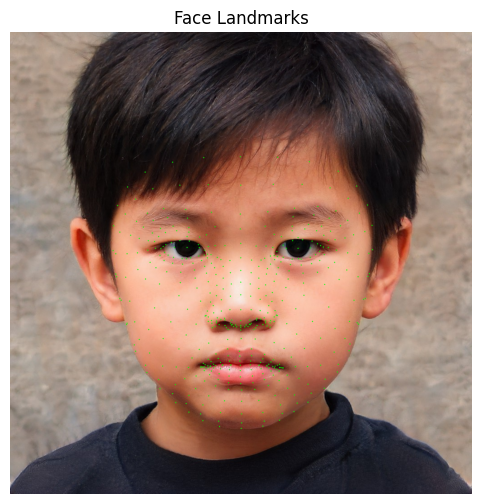

In [9]:
rgb = cv2.cvtColor(raw_cv, cv2.COLOR_BGR2RGB)

face_res = mp_face.process(rgb)
hand_res = mp_hands.process(rgb)

if not face_res.multi_face_landmarks:
    raise Exception("❌ No face detected — verify image.")

if hand_res.multi_hand_landmarks:
    print("⚠ Hand detected — this image would be rejected.")

if len(face_res.multi_face_landmarks) > 1:
    print("⚠ Multiple faces detected — would be rejected.")

# Preview landmarks
annotated = raw_cv.copy()
for lm in face_res.multi_face_landmarks[0].landmark:
    x = int(lm.x * annotated.shape[1])
    y = int(lm.y * annotated.shape[0])
    cv2.circle(annotated, (x, y), 1, (0,255,0), -1)

plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title("Face Landmarks")
plt.axis("off")


# 🎯 Pose Estimation (Yaw, Pitch, Roll)

We compute pose from a simplified set of landmarks:

- Yaw  → head turn left/right  
- Pitch → head looking up/down  
- Roll → head tilt  

This determines whether the face is suitable for
the Face Stats alignment rules.

In [10]:
def compute_pose(landmarks):
    left_eye = np.mean([[landmarks[i].x, landmarks[i].y, landmarks[i].z]
                        for i in [33, 133]], axis=0)
    right_eye = np.mean([[landmarks[i].x, landmarks[i].y, landmarks[i].z]
                         for i in [362, 263]], axis=0)
    nose = np.array([landmarks[1].x, landmarks[1].y, landmarks[1].z])

    yaw = right_eye[0] - left_eye[0]
    pitch = ((left_eye[1] + right_eye[1]) / 2) - nose[1]
    roll = right_eye[1] - left_eye[1]
    return float(yaw), float(pitch), float(roll)

lms = face_res.multi_face_landmarks[0].landmark
yaw, pitch, roll = compute_pose(lms)

print("Yaw  :", yaw)
print("Pitch:", pitch)
print("Roll :", roll)


Yaw  : 0.24802865087985992
Pitch: -0.14994218200445175
Roll : -2.796947956085205e-05


# 🎛 Face Alignment

This cell rotates the image so the eyes are level.
This ensures:

- Consistent orientation  
- Better PCA/composite results  
- Better attractiveness ratings clarity  

We will display:
1. Raw image  
2. Rotated image  

(-0.5, 1023.5, 1023.5, -0.5)

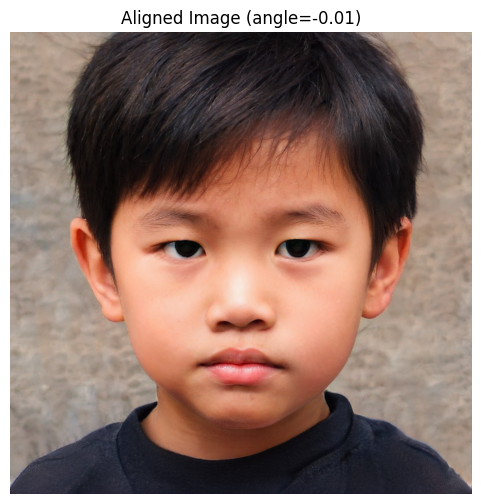

In [11]:
h, w = raw_cv.shape[:2]

left_eye = np.mean([[lms[i].x * w, lms[i].y * h] for i in [33, 133]], axis=0)
right_eye = np.mean([[lms[i].x * w, lms[i].y * h] for i in [362, 263]], axis=0)

dy = right_eye[1] - left_eye[1]
dx = right_eye[0] - left_eye[0]
angle = np.degrees(np.arctan2(dy, dx))

center = (w//2, h//2)
M = cv2.getRotationMatrix2D(center, angle, 1.0)
aligned = cv2.warpAffine(raw_cv, M, (w, h))

plt.imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))
plt.title(f"Aligned Image (angle={angle:.2f})")
plt.axis("off")


# ✂️ Cropping to Canonical Face Region

We compute a bounding box around the rotated landmarks,
then add padding:

- 25% horizontal padding  
- 35% vertical padding  

Then crop and preview the box before resizing to 512×512.

(-0.5, 957.5, 957.5, -0.5)

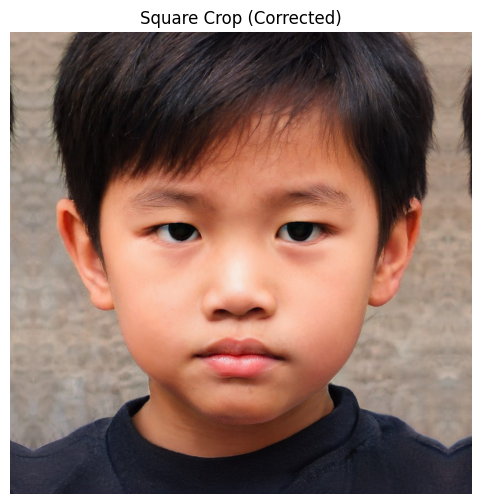

In [16]:
# Rotate landmarks
rot_lms = []
for lm in lms:
    x = lm.x * w
    y = lm.y * h
    px = M[0,0]*x + M[0,1]*y + M[0,2]
    py = M[1,0]*x + M[1,1]*y + M[1,2]
    rot_lms.append([px, py])

rot_lms = np.array(rot_lms)

xs = rot_lms[:,0]
ys = rot_lms[:,1]

x1, x2 = int(xs.min()), int(xs.max())
y1, y2 = int(ys.min()), int(ys.max())

# Base padding
pad_x = int((x2 - x1) * 0.25)
pad_y = int((y2 - y1) * 0.35)

cx1 = max(x1 - pad_x, 0)
cx2 = min(x2 + pad_x, w)
cy1 = max(y1 - pad_y, 0)
cy2 = min(y2 + pad_y, h)

# Extract preliminary (possibly non-square) crop
crop = aligned[cy1:cy2, cx1:cx2]

# ==========================================
# MAKE CROP SQUARE BEFORE RESIZE (NEW FIX)
# ==========================================

h_c, w_c = crop.shape[:2]
side = max(h_c, w_c)

# Compute padding needed
pad_top = (side - h_c) // 2
pad_bottom = side - h_c - pad_top
pad_left = (side - w_c) // 2
pad_right = side - w_c - pad_left

crop_square = cv2.copyMakeBorder(
    crop,
    pad_top, pad_bottom, pad_left, pad_right,
    cv2.BORDER_REFLECT_101
)

plt.imshow(cv2.cvtColor(crop_square, cv2.COLOR_BGR2RGB))
plt.title("Square Crop (Corrected)")
plt.axis("off")


# 🔄 Resize & Color Normalize (Final 512×512)

This step ensures:

- All images exactly 512×512  
- Mild contrast enhancement  
- Uniform color  
- Consistent brightness  

This forms the final input for ALL downstream tabs.

(-0.5, 511.5, 511.5, -0.5)

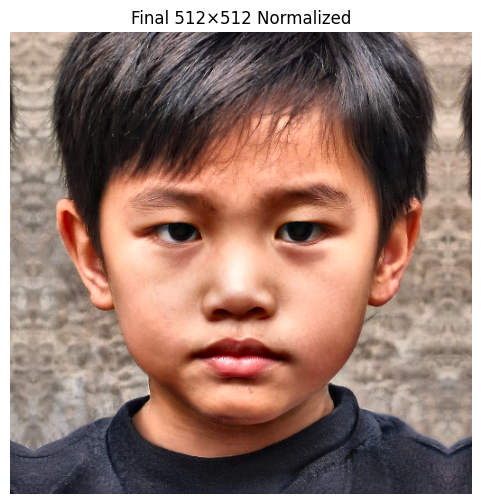

In [17]:
# Resize
final_512 = cv2.resize(crop_square, (512, 512), interpolation=cv2.INTER_LANCZOS4)

# Mild normalization (CLAHE)
lab = cv2.cvtColor(final_512, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
l2 = clahe.apply(l)
lab2 = cv2.merge((l2,a,b))
final_norm = cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)

plt.imshow(cv2.cvtColor(final_norm, cv2.COLOR_BGR2RGB))
plt.title("Final 512×512 Normalized")
plt.axis("off")


# 💾 Save Final Output + Metadata

This cell writes:
- final 512×512 face
- metadata JSON
- optional aligned image
- optional crop image

Exactly as used in the full pipeline.

In [15]:
OUT_DIR = "./FaceStats_preprocessed_test"
META_DIR = "./FaceStats_metadata_test"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

base = os.path.splitext(os.path.basename(IMG_PATH))[0]

out_path = os.path.join(OUT_DIR, f"{base}_processed.png")
meta_path = os.path.join(META_DIR, f"{base}.json")

# Save final normalized
Image.fromarray(cv2.cvtColor(final_norm, cv2.COLOR_BGR2RGB)).save(out_path)

# Save metadata
meta = {
    "id": base,
    "raw_path": IMG_PATH,
    "processed_path": out_path,
    "pose": {"yaw": yaw, "pitch": pitch, "roll": roll},
    "crop_box": [int(cx1), int(cy1), int(cx2), int(cy2)],
    "angle": float(angle),
    "resolution_final": "512x512"
}

with open(meta_path, "w") as f:
    json.dump(meta, f, indent=4)

print("Saved image to:", out_path)
print("Saved metadata to:", meta_path)


Saved image to: ./FaceStats_preprocessed_test/SFHQ_pt4_00000001_processed.png
Saved metadata to: ./FaceStats_metadata_test/SFHQ_pt4_00000001.json
